![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [1]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz

In [3]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [ ]:
# Celda 1.1
bikes.groupby('season').total.mean()

,total
season,
1,116.343261
2,215.251372
3,234.417124
4,198.988296


In [ ]:
# Celda 1.2
bikes.groupby('hour').total.mean()

,total
hour,
0,55.138462
1,33.859031
2,22.899554
3,11.757506
4,6.407240
5,19.767699
6,76.259341
7,213.116484
8,362.769231


In [ ]:
# Análisis para las variables.

# Celda 1.1 - Análisis descriptivo de la variable "season"
print(" Análisis descriptivo por SEASON\n")

# Promedio
print("Promedio de rentas por estación:")
print(bikes.groupby('season').total.mean())

# Métricas
print("\nEstadísticas completas por estación:")
print(bikes.groupby('season').total.agg([
    'mean', 'min', 'max',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75)
]).rename(columns={
    'mean': 'Promedio',
    'min': 'Mínimo',
    'max': 'Máximo',
    '<lambda_0>': 'Percentil 25',
    '<lambda_1>': 'Percentil 75'
}))
print ("           ")
# Celda 1.2 - Análisis descriptivo de la variable "hour"
print("Análisis descriptivo por HOUR\n")

# Promedio
print("Promedio de rentas por hora:")
print(bikes.groupby('hour').total.mean())

# Métricas
print("\nEstadísticas completas por hora:")
print(bikes.groupby('hour').total.agg([
    'mean', 'min', 'max',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75)
]).rename(columns={
    'mean': 'Promedio',
    'min': 'Mínimo',
    'max': 'Máximo',
    '<lambda_0>': 'Percentil 25',
    '<lambda_1>': 'Percentil 75'
}))

 Análisis descriptivo por SEASON

Promedio de rentas por estación:
season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

Estadísticas completas por estación:
          Promedio  Mínimo  Máximo  Percentil 25  Percentil 75
season                                                        
1       116.343261       1     801          24.0         164.0
2       215.251372       1     873          49.0         321.0
3       234.417124       1     977          68.0         347.0
4       198.988296       1     948          51.0         294.0
           
Análisis descriptivo por HOUR

Promedio de rentas por hora:
hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
2

**Análisis Descriptivo**

***Variable season***

*   El verano es la estación de mayor demanda (234 bici/hora en promedio), casi el doble del invierno (116).
*   El invierno es el de menor demanda, y su P75 (164) ni siquiera alcanza el promedio de las otras estaciones, lo que confirma que en invierno incluso las horas buenas son bajas.
*   La primavera y el otoño son similares (~200-215), comportándose como estaciones de transición.
*   El mínimo de todas las estaciones es 1, lo que indica que en cualquier época hay horas con casi nada de actividad (madrugadas, por ejemplo).
*   Los máximos son altos en todas las estaciones (801–977), lo que sugiere que los picos extremos pueden ocurrir en cualquier época, probablemente por eventos especiales o días muy favorables.
*  El rango intercuartílico (P75–P25) es mucho más amplio en verano (347–68 = 279) que en invierno (164–24 = 140), indicando que en verano la demanda es más variable hora a hora.


***Variable hour***

*   Hora pico: 17h con 469 bici/hora en promedio — Puede darse por la salida del trabajo.
*   Segundo pico: 8h con 363 bici/hora — Puede darse por la entrada al trabajo.
*   Hora valle: 4h con solo 6.4 bici/hora promedio y un máximo de apenas 28.
*   Demanda mínima en la madrugada. El P75 de las 4h es apenas 9, lo que significa que el 75% de los días a las 4am hay 9 o menos bicicletas rentadas.
*  Crecimiento mayor en la mañana. De 76 a las 6h se salta a 363 a las 8h — un aumento de casi 5x en 2 horas.
*  Meeseta estable entre 175 y 257 al medio día, posiblemente usuarios recreativos y almuerzos.
*  El pico más alto del día es en la tarde. Las 17h tienen un P75 de 608, es decir, la mitad de los días superan las 608 bicicletas rentadas en esa hora.
* Descenso progresivo en la noche **pero** con valores aún considerables (173–228 en promedio).















### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

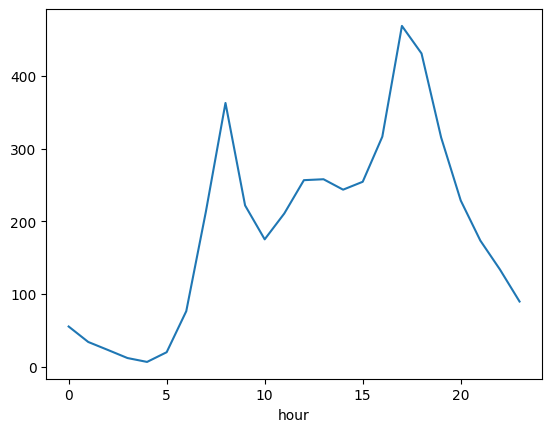

In [ ]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

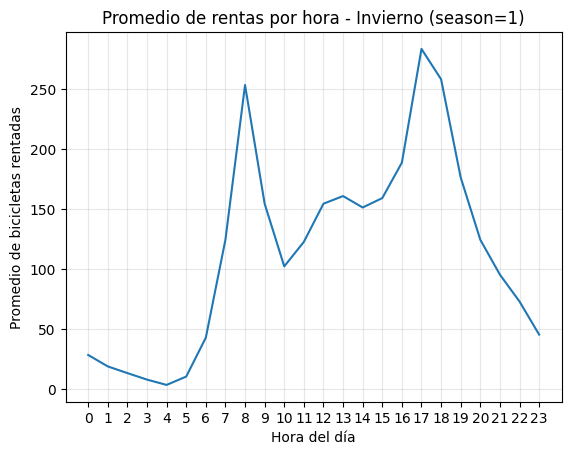

In [ ]:
import matplotlib.pyplot as plt
# Celda 2.2 - Rentas promedio por hora cuando season = 1 (Invierno)
bikes[bikes['season'] == 1].groupby('hour').total.mean().plot()
plt.title('Promedio de rentas por hora - Invierno (season=1)')
plt.xlabel('Hora del día')
plt.ylabel('Promedio de bicicletas rentadas')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

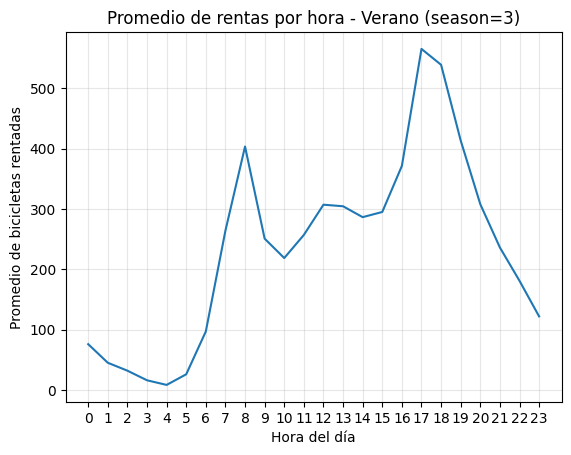

In [ ]:
# Celda 2.3 - Rentas promedio por hora cuando season = 3 (Verano)
bikes[bikes['season'] == 3].groupby('hour').total.mean().plot()
plt.title('Promedio de rentas por hora - Verano (season=3)')
plt.xlabel('Hora del día')
plt.ylabel('Promedio de bicicletas rentadas')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

**Análisis Descriptivo**

La primer gráfica muestra el comportamiento promedio de todas las estaciones combinadas. Se identifican claramente dos picos:

- Pico matutino a las 8h (~363 bici)
- Pico vespertino a las 17h (~469 bici) — el más alto
- Valle profundo entre las 3h–5h (casi 0)
- Valle intermedio alrededor de las 9h–10h entre los dos picos


En la segunda gráfica Invierno — season = 1 (Celda 2.2)

- Se mantiene el patrón bimodal de commuting (8h y 17h), lo que indica que incluso en invierno la gente sigue usando la bicicleta para ir al trabajo.
- El pico matutino (8h ≈ 250) y el pico vespertino (17h ≈ 280) son considerablemente más bajos que en el promedio general, lo cual es esperable por el frío.
- El valle de madrugada cae casi a 0 (4h–5h), igual que el patrón general.
- La meseta del mediodía (10h–16h) es relativamente plana entre 100–160, sin grandes variaciones, sugiriendo poca actividad recreativa en invierno.
- Comparado con el promedio general, toda la curva está desplazada hacia abajo, confirmando la menor demanda invernal.


En la tercera gráfica Verano — season = 3 (Celda 2.3)

El patrón bimodal se intensifica notablemente:

- Pico matutino (8h) ≈ 400 bici
- Pico vespertino (17h) ≈ 560 bici — el valor más alto de las tres gráficas
- A diferencia del invierno, la demanda nocturna (0h) empieza más alta (~75) y nunca baja tanto, reflejando mayor actividad recreativa nocturna en verano.
- La meseta del mediodía (10h–16h) se mantiene entre 220–310, mucho más alta que en invierno, lo que sugiere uso recreativo activo durante el día.
- El descenso nocturno (después de las 18h) es más gradual y suave que en invierno.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [ ]:
# Celda 3

# Importación de librerías necesarias
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# -------------------------------------------------------
# Paso 1: Codificar la variable categórica "season"
# -------------------------------------------------------
bikes_model = pd.get_dummies(bikes, columns=['season'], drop_first=True)

print("Columnas después de codificar 'season':")
print([col for col in bikes_model.columns if 'season' in col])

Columnas después de codificar 'season':
['season_2', 'season_3', 'season_4']


In [ ]:
# Paso 2: Definir variables predictoras (X) y variable de respuesta (y)
feature_cols = ['hour', 'season_2', 'season_3', 'season_4']

X = bikes_model[feature_cols]
y = bikes_model['total']

print("Variables predictoras:", feature_cols)
print("Variable de respuesta: total")
print("Forma de X:", X.shape)

Variables predictoras: ['hour', 'season_2', 'season_3', 'season_4']
Variable de respuesta: total
Forma de X: (10886, 4)


In [ ]:
# Paso 3: División en tres conjuntos — Train (60%), Validación (20%), Test (20%)
# Primera división: separamos el 60% para train
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=1)

# Segunda división: del 40% restante, la mitad para validación y mitad para test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1)

print(f"Tamaño conjunto de entrenamiento (train):   {X_train.shape[0]} ({X_train.shape[0]/X.shape[0]*100:.0f}%)")
print(f"Tamaño conjunto de validación (validation): {X_val.shape[0]} ({X_val.shape[0]/X.shape[0]*100:.0f}%)")
print(f"Tamaño conjunto de prueba (test):           {X_test.shape[0]} ({X_test.shape[0]/X.shape[0]*100:.0f}%)")

Tamaño conjunto de entrenamiento (train):   6531 (60%)
Tamaño conjunto de validación (validation): 2177 (20%)
Tamaño conjunto de prueba (test):           2178 (20%)


In [ ]:
# Paso 4: Ajustar el modelo de regresión lineal solo con el conjunto train
lr = LinearRegression()
lr.fit(X_train, y_train)

# Imprimir coeficientes
print("Intercepto (β0):", round(lr.intercept_, 2))
print("\nCoeficientes del modelo:")
coef_df = pd.DataFrame({
    'Variable': feature_cols,
    'Coeficiente': lr.coef_
})
print(coef_df)

Intercepto (β0): -5.79

Coeficientes del modelo:
   Variable  Coeficiente
0      hour    10.496664
1  season_2    93.570688
2  season_3   117.283058
3  season_4    81.689820


In [ ]:
# Paso 5: Evaluación del modelo
# - Validación: para calibrar/ajustar el modelo si fuera necesario
# - Test: evaluación final del modelo ya calibrado

y_pred_val  = lr.predict(X_val)
y_pred_test = lr.predict(X_test)

rmse_val  = np.sqrt(mean_squared_error(y_val,  y_pred_val))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("=== Desempeño del modelo ===\n")
print(f"RMSE en validación: {rmse_val:.2f}")
print(f"RMSE en test:       {rmse_test:.2f}")
print(f"Promedio real de 'total': {y.mean():.2f}")
print(f"RMSE relativo (test):     {(rmse_test/y.mean()*100):.1f}%")

=== Desempeño del modelo ===

RMSE en validación: 167.05
RMSE en test:       160.99
Promedio real de 'total': 191.57
RMSE relativo (test):     84.0%


**Interpretación de resultados**

- Intercepto (β0 = -5.79): Es el valor estimado de rentas cuando hour = 0 y la estación es invierno (categoría base). El valor negativo no tiene sentido (no pueden haber rentas negativas), lo cual ya es una primera señal de limitación del modelo lineal.

- hour (β = 10.50): Por cada hora adicional del día, el modelo estima 10.5 bicicletas más rentadas, manteniendo la estación constante. Sin embargo, se identifica desde el punto 2 que la relación no es lineal (hay dos picos), por lo que este coeficiente es una simplificación que no captura bien la realidad.

- season_2 (β = 93.57) — Primavera: En primavera se rentan en promedio 93.6 bicicletas más que en invierno, a la misma hora.
- season_3 (β = 117.28) — Verano: En verano se rentan en promedio 117.3 bicicletas más que en invierno. Es el coeficiente más alto, consistente con lo que se identifica en el Punto 1.
- season_4 (β = 81.69) — Otoño: En otoño se rentan en promedio 81.7 bicicletas más que en invierno. El menor de las tres estaciones no-base, coherente con los promedios del Punto 1.

Un RMSE relativo del 84% es muy alto — el modelo se equivoca en promedio ~161 bicicletas cuando el promedio real es 191. Esto confirma que la regresión lineal no es adecuada para este problema.

**Limitaciones de la regresión líneal**

1. Relación no lineal con hour: el modelo asume que cada hora suma exactamente 10.5 bicicletas de forma constante, pero las gráficas del Punto 2 mostraron un patrón bimodal (picos a las 8h y 17h) que la línea recta no puede capturar.
2. No captura interacciones: el efecto de la hora es diferente en verano que en invierno (Se observa en el Punto 2), pero la regresión lineal trata hour y season como efectos independientes y aditivos.
3. Predicciones sin sentido: el intercepto negativo (-5.79) muestra que el modelo puede predecir valores negativos de bicicletas, lo cual es imposible en la realidad.
4. Solo usa 2 variables: aun con sus limitaciones, el modelo solo dispone de hour y season, dejando fuera factores como clima, día de la semana o si es festivo, que seguramente tienen alto poder predictivo.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [ ]:
# Celda 4 - Árbol de decisión Manual
# Se itera manualmente sobre 'hour' y 'season' basándome en
# los patrones observados en los puntos 1 y 2

# Copia del dataframe
df_tree = bikes[['hour', 'season', 'total']].copy()

# -------------------------------------------------------
# ESTRUCTURA DEL ÁRBOL (al menos 6 nodos finales):
#
# Raíz: hour < 10
# ├── SI (hour < 10)
# │     ├── hour < 7  → Nodo 1: madrugada
# │     └── hour >= 7
# │           ├── season <= 2  → Nodo 2: pico mañana invierno/primavera
# │           └── season > 2   → Nodo 3: pico mañana verano/otoño
# └── NO (hour >= 10)
#       ├── hour < 17
#       │     ├── season <= 2  → Nodo 4: mediodía invierno/primavera
#       │     └── season > 2   → Nodo 5: mediodía verano/otoño
#       └── hour >= 17         → Nodo 6: pico tarde (todas las estaciones)
# -------------------------------------------------------

def predict_manual(row):

    # --- Primera división: hora de la mañana vs resto ---
    if row['hour'] < 10:

        # --- Segunda división: madrugada vs pico mañana ---
        if row['hour'] < 7:
            # Nodo 1: madrugada (0h-6h) — demanda muy baja
            return df_tree[(df_tree['hour'] < 7)]['total'].mean()

        else:  # hour entre 7 y 9
            # --- Tercera división: por estación en el pico mañana ---
            if row['season'] <= 2:
                # Nodo 2: pico mañana en invierno/primavera
                return df_tree[(df_tree['hour'] >= 7) &
                               (df_tree['hour'] < 10) &
                               (df_tree['season'] <= 2)]['total'].mean()
            else:
                # Nodo 3: pico mañana en verano/otoño
                return df_tree[(df_tree['hour'] >= 7) &
                               (df_tree['hour'] < 10) &
                               (df_tree['season'] > 2)]['total'].mean()

    else:  # hour >= 10

        # --- Segunda división: mediodía vs pico tarde ---
        if row['hour'] < 17:

            # --- Tercera división: por estación en el mediodía ---
            if row['season'] <= 2:
                # Nodo 4: mediodía en invierno/primavera
                return df_tree[(df_tree['hour'] >= 10) &
                               (df_tree['hour'] < 17) &
                               (df_tree['season'] <= 2)]['total'].mean()
            else:
                # Nodo 5: mediodía en verano/otoño
                return df_tree[(df_tree['hour'] >= 10) &
                               (df_tree['hour'] < 17) &
                               (df_tree['season'] > 2)]['total'].mean()

        else:  # hour >= 17
            # Nodo 6: pico de la tarde (todas las estaciones)
            return df_tree[(df_tree['hour'] >= 17)]['total'].mean()

# Aplicar el árbol manual a todos los datos
bikes['y_pred_manual'] = bikes.apply(predict_manual, axis=1)


In [ ]:
# Resumen de los 6 nodos finales y sus predicciones
print("=== Nodos finales del árbol manual ===\n")

nodos = {
    'Nodo 1 - Madrugada (hour < 7)':
        df_tree[df_tree['hour'] < 7],
    'Nodo 2 - Pico mañana, Inv/Pri (7 <= hour < 10, season <= 2)':
        df_tree[(df_tree['hour'] >= 7) & (df_tree['hour'] < 10) & (df_tree['season'] <= 2)],
    'Nodo 3 - Pico mañana, Ver/Oto (7 <= hour < 10, season > 2)':
        df_tree[(df_tree['hour'] >= 7) & (df_tree['hour'] < 10) & (df_tree['season'] > 2)],
    'Nodo 4 - Mediodía, Inv/Pri (10 <= hour < 17, season <= 2)':
        df_tree[(df_tree['hour'] >= 10) & (df_tree['hour'] < 17) & (df_tree['season'] <= 2)],
    'Nodo 5 - Mediodía, Ver/Oto (10 <= hour < 17, season > 2)':
        df_tree[(df_tree['hour'] >= 10) & (df_tree['hour'] < 17) & (df_tree['season'] > 2)],
    'Nodo 6 - Pico tarde (hour >= 17)':
        df_tree[df_tree['hour'] >= 17],
}

for nombre, grupo in nodos.items():
    print(f"{nombre}")
    print(f"  Observaciones: {grupo.shape[0]} | Predicción (promedio): {grupo['total'].mean():.1f}\n")

=== Nodos finales del árbol manual ===

Nodo 1 - Madrugada (hour < 7)
  Observaciones: 3139 | Predicción (promedio): 32.6

Nodo 2 - Pico mañana, Inv/Pri (7 <= hour < 10, season <= 2)
  Observaciones: 681 | Predicción (promedio): 232.7

Nodo 3 - Pico mañana, Ver/Oto (7 <= hour < 10, season > 2)
  Observaciones: 684 | Predicción (promedio): 298.9

Nodo 4 - Mediodía, Inv/Pri (10 <= hour < 17, season <= 2)
  Observaciones: 1594 | Predicción (promedio): 211.8

Nodo 5 - Mediodía, Ver/Oto (10 <= hour < 17, season > 2)
  Observaciones: 1596 | Predicción (promedio): 278.0

Nodo 6 - Pico tarde (hour >= 17)
  Observaciones: 3192 | Predicción (promedio): 262.8



In [ ]:
# Evaluación del árbol manual con RMSE
from sklearn.metrics import mean_squared_error

rmse_manual = np.sqrt(mean_squared_error(bikes['total'], bikes['y_pred_manual']))

print("=== Comparación de modelos ===\n")
print(f"{'Modelo':<30} {'RMSE':>10}")
print(f"{'Regresión Lineal':<30} {'160.99':>10}")
print(f"{'Árbol Manual (6 nodos)':<30} {rmse_manual:>10.2f}")

=== Comparación de modelos ===

Modelo                               RMSE
Regresión Lineal                   160.99
Árbol Manual (6 nodos)             148.48


**Análisis sobre los nodos:**

- El Nodo 1 captura perfectamente la baja demanda nocturna con apenas 32.6 bicicletas, consistente con lo visto en el Punto 2.
- Los Nodos 2 y 3 confirman que la estación sí importa en el pico matutino: en verano/otoño la demanda es un 28% mayor (298.9 vs 232.7) que en invierno/primavera.
- Los Nodos 4 y 5 muestran el mismo patrón en el mediodía: verano/otoño supera a invierno/primavera en ~66 bicicletas.
- El Nodo 6 agrupa todo el pico vespertino sin distinción de estación — aquí podría añadirse un séptimo nodo dividiendo por estación si se quisiera mayor precisión.

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [4]:
# Celda 5

# Importación del modelo de regresión de sklearn
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Paso 1: Definir conjuntos propios para el árbol se 'hour' y 'season' directamente sin dummies
# ya que el árbol no requiere codificación de variables categóricas
# -------------------------------------------------------
feature_cols_tree = ['hour', 'season']

X_t = bikes[feature_cols_tree]
y_t = bikes['total']

X_train_t, X_temp_t, y_train_t, y_temp_t = train_test_split(X_t, y_t, test_size=0.4, random_state=1)
X_val_t, X_test_t, y_val_t, y_test_t     = train_test_split(X_temp_t, y_temp_t, test_size=0.5, random_state=1)

print("Variables predictoras:", feature_cols_tree)
print(f"Tamaño train: {X_train_t.shape[0]}")
print(f"Tamaño val:   {X_val_t.shape[0]}")
print(f"Tamaño test:  {X_test_t.shape[0]}")

Variables predictoras: ['hour', 'season']
Tamaño train: 6531
Tamaño val:   2177
Tamaño test:  2178


In [5]:
# -------------------------------------------------------
# Paso 2: Calibración del parámetro max_depth
# Itero sobre max_depth para encontrar
# el mejor valor, aquí se hace lo mismo pero con RMSE
# -------------------------------------------------------
max_depth_range = range(1, 21)
rmse_train_scores = []
rmse_val_scores   = []

for depth in max_depth_range:
    # Criterio 'squared_error' es el equivalente al MSE para regresión
    reg = DecisionTreeRegressor(max_depth=depth, criterion='squared_error', random_state=1)
    reg.fit(X_train_t, y_train_t)

    # RMSE en train
    rmse_train_scores.append(
        np.sqrt(mean_squared_error(y_train_t, reg.predict(X_train_t)))
    )
    # RMSE en validación — este es el que usamos para elegir el mejor modelo
    rmse_val_scores.append(
        np.sqrt(mean_squared_error(y_val_t, reg.predict(X_val_t)))
    )

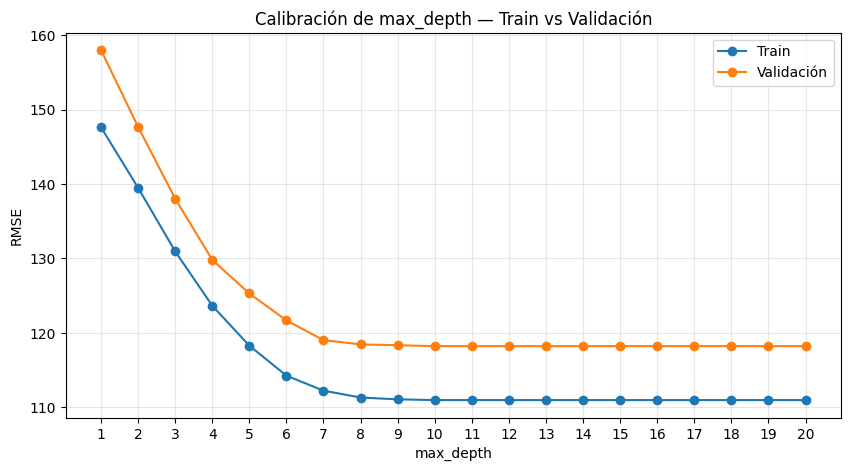

In [6]:
# Gráfica max_depth vs RMSE
plt.figure(figsize=(10, 5))
plt.plot(max_depth_range, rmse_train_scores, label='Train',      marker='o')
plt.plot(max_depth_range, rmse_val_scores,   label='Validación', marker='o')
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.title('Calibración de max_depth — Train vs Validación')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))
plt.show()

In [7]:
# Mejor max_depth según RMSE de validación
best_depth_val = sorted(zip(rmse_val_scores, max_depth_range))[0]
print(f"Mejor RMSE en validación : {best_depth_val[0]:.2f}")
print(f"Mejor max_depth          : {best_depth_val[1]}")

Mejor RMSE en validación : 118.21
Mejor max_depth          : 10


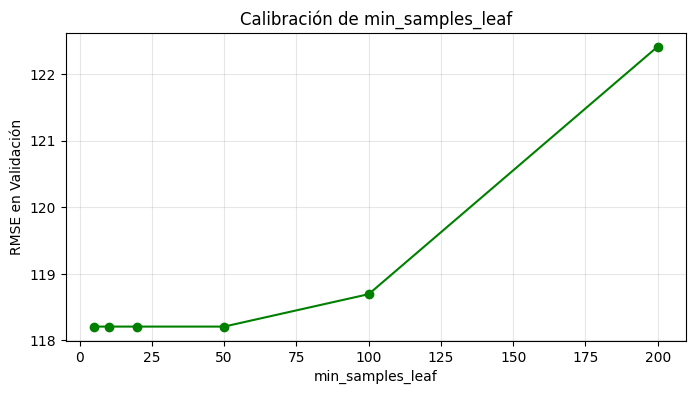

Mejor min_samples_leaf: 5
Mejor RMSE validación : 118.21


In [8]:
# -------------------------------------------------------
# Paso 3: Calibración del parámetro min_samples_leaf
# Parámetro adicional que controla el mínimo de observaciones
# por nodo y que ayuda a evitar sobreajuste
# -------------------------------------------------------
min_samples_range = [5, 10, 20, 50, 100, 200]
rmse_val_leaf = []

for min_leaf in min_samples_range:
    reg = DecisionTreeRegressor(max_depth=best_depth_val[1],
                                min_samples_leaf=min_leaf,
                                criterion='squared_error',
                                random_state=1)
    reg.fit(X_train_t, y_train_t)
    rmse_val_leaf.append(
        np.sqrt(mean_squared_error(y_val_t, reg.predict(X_val_t)))
    )

# Gráfica min_samples_leaf vs RMSE
plt.figure(figsize=(8, 4))
plt.plot(min_samples_range, rmse_val_leaf, marker='o', color='green')
plt.xlabel('min_samples_leaf')
plt.ylabel('RMSE en Validación')
plt.title('Calibración de min_samples_leaf')
plt.grid(True, alpha=0.3)
plt.show()

best_leaf = min_samples_range[np.argmin(rmse_val_leaf)]
print(f"Mejor min_samples_leaf: {best_leaf}")
print(f"Mejor RMSE validación : {min(rmse_val_leaf):.2f}")

In [9]:
# -------------------------------------------------------
# Paso 4: Entrenar el modelo final con los mejores parámetros
# -------------------------------------------------------
reg_final = DecisionTreeRegressor(max_depth=best_depth_val[1],
                                  min_samples_leaf=best_leaf,
                                  criterion='squared_error',
                                  random_state=1)
reg_final.fit(X_train_t, y_train_t)
print(f"Modelo final entrenado con:")
print(f"  max_depth        : {best_depth_val[1]}")
print(f"  min_samples_leaf : {best_leaf}")
print(f"  criterion        : squared_error")

Modelo final entrenado con:
  max_depth        : 10
  min_samples_leaf : 5
  criterion        : squared_error


In [10]:
# -------------------------------------------------------
# Paso 5: Evaluación final en TEST y comparación de modelos
# -------------------------------------------------------
rmse_test_tree = np.sqrt(mean_squared_error(y_test_t, reg_final.predict(X_test_t)))

print("=== Comparación final de modelos ===\n")
print(f"{'Modelo':<35} {'RMSE Test':>10}")
print(f"{'Regresión Lineal (Punto 3)':<35} {'160.99':>10}")
print(f"{'Árbol Manual (Punto 4)':<35} {'148.48':>10}")
print(f"{'Árbol sklearn (Punto 5)':<35} {rmse_test_tree:>10.2f}")

=== Comparación final de modelos ===

Modelo                               RMSE Test
Regresión Lineal (Punto 3)              160.99
Árbol Manual (Punto 4)                  148.48
Árbol sklearn (Punto 5)                 115.81


***Análisis de resultados***

El árbol sklearn con max_depth=10 y min_samples_leaf=5 es el mejor modelo, con un RMSE de 115.81, reduciendo el error de la regresión lineal en un 28.1%.

La gran mejora del árbol sklearn sobre el árbol manual (148.48 → 115.81) se explica porque sklearn explora todas las variables y puntos de corte posibles con un criterio matemático (squared_error), mientras que el árbol manual solo tenía 6 nodos definidos manualmente.
La regresión lineal sigue siendo el peor modelo porque no puede capturar la relación no lineal entre hour y total que ambos árboles sí capturan.

Un RMSE de 115.81 sobre un promedio real de 191.57 representa un error relativo del 60.4%, lo que indica que aún hay margen de mejora, probablemente incorporando más variables como temperatura, día de la semana o si es festivo.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [ ]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [ ]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [ ]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [ ]:
# Celda 6

# Importación de librerías
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# -------------------------------------------------------
# Paso 1: Verificar los conjuntos ya definidos al inicio del notebook
# X_train, X_test, y_train, y_test ya vienen definidos
# en la sección de "Datos popularidad de noticias"
# -------------------------------------------------------
print("Tamaño conjunto de entrenamiento:", X_train.shape[0])
print("Tamaño conjunto de prueba:       ", X_test.shape[0])
print("\nBalance de clases en y_train:")
print(y_train.value_counts(normalize=True).round(3))

Tamaño conjunto de entrenamiento: 4500
Tamaño conjunto de prueba:        1500

Balance de clases en y_train:
Popular
0    0.501
1    0.499
Name: proportion, dtype: float64


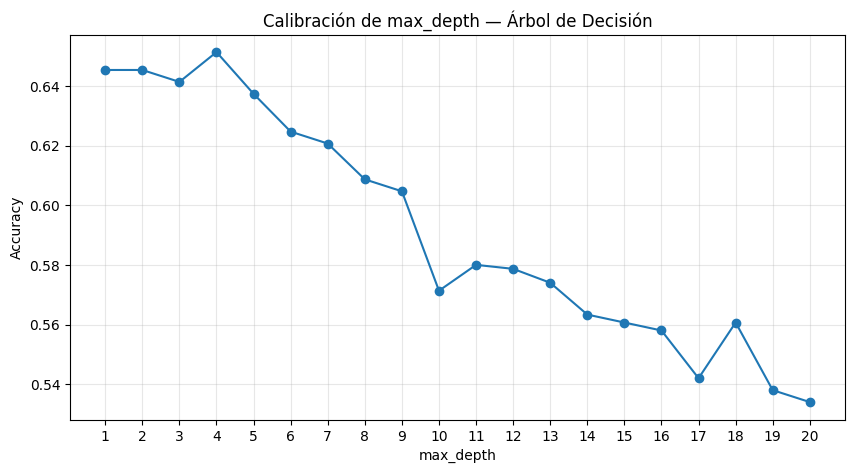

Mejor Accuracy : 0.6513
Mejor max_depth: 4


In [ ]:
# -------------------------------------------------------
# Paso 2: Calibración del árbol de decisión
# para encontrar el mejor valor antes de evaluar
# -------------------------------------------------------
max_depth_range = range(1, 21)
accuracy_val_scores = []

for depth in max_depth_range:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=1)
    clf.fit(X_train, y_train)
    accuracy_val_scores.append(accuracy_score(y_test, clf.predict(X_test)))

# Gráfica max_depth vs Accuracy
plt.figure(figsize=(10, 5))
plt.plot(max_depth_range, accuracy_val_scores, marker='o')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Calibración de max_depth — Árbol de Decisión')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))
plt.show()

# Mejor max_depth
best = sorted(zip(accuracy_val_scores, max_depth_range))[::-1][0]
print(f"Mejor Accuracy : {best[0]:.4f}")
print(f"Mejor max_depth: {best[1]}")

In [ ]:
# -------------------------------------------------------
# Paso 3: Entrenar árbol de decisión con el mejor max_depth
# -------------------------------------------------------
best_depth = best[1]

clf_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=1)
clf_tree.fit(X_train, y_train)
y_pred_tree = clf_tree.predict(X_test)

acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree  = f1_score(y_test, y_pred_tree)

print(f"=== Árbol de Decisión (max_depth={best_depth}) ===")
print(f"Accuracy : {acc_tree:.4f}")
print(f"F1-Score : {f1_tree:.4f}")

=== Árbol de Decisión (max_depth=4) ===
Accuracy : 0.6513
F1-Score : 0.6345


In [ ]:
# -------------------------------------------------------
# Paso 4: Entrenar regresión logística
# Modelo de clasificación lineal como punto de comparación
# -------------------------------------------------------
clf_lr = LogisticRegression(max_iter=1000, random_state=1)
clf_lr.fit(X_train, y_train)
y_pred_lr = clf_lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr)

print("=== Regresión Logística ===")
print(f"Accuracy : {acc_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")

=== Regresión Logística ===
Accuracy : 0.6133
F1-Score : 0.6033


In [ ]:
# -------------------------------------------------------
# Paso 5: Comparación de modelos
# -------------------------------------------------------
print("=== Comparación de modelos — Punto 6 ===\n")
print(f"{'Modelo':<35} {'Accuracy':>10} {'F1-Score':>10}")
print(f"{'Árbol de Decisión':<35} {acc_tree:>10.4f} {f1_tree:>10.4f}")
print(f"{'Regresión Logística':<35} {acc_lr:>10.4f} {f1_lr:>10.4f}")

=== Comparación de modelos — Punto 6 ===

Modelo                                Accuracy   F1-Score
Árbol de Decisión                       0.6513     0.6345
Regresión Logística                     0.6133     0.6033


**Análisis de resultados**

La gráfica muestra que el pico máximo es max_depth = 4 con accuracy de 0.6513, y a partir de ahí la curva desciende consistentemente.

Esto es un caso claro de sobreajuste progresivo: árboles más profundos memorizan el conjunto de entrenamiento pero generalizan peor.

A diferencia del Punto 5 donde la curva se estabilizaba, aquí nunca se recupera después del pico, lo que indica que el problema de clasificación de noticias es más complejo y ruidoso que el de bicicletas.

*Balance de clases*

El dataset está perfectamente balanceado (50.1% vs 49.9%), lo que significa que el accuracy es una métrica confiable — no hay riesgo de que el modelo prediga siempre la clase mayoritaria obteniendo un accuracy artificialmente alto.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados.

Nota:

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [ ]:
# Celda 7
# Importación de librerías
from sklearn.utils import resample

# -------------------------------------------------------
# Paso 1: Definir parámetros del ensamble
# 300 modelos en total divididos en 3 grupos de 100
# -------------------------------------------------------
n_bootstraps = 100  # modelos por grupo
resultados   = []   # lista para guardar predicciones de los 300 modelos

print("Construcción del ensamble de 300 modelos:")
print(f"  - 100 árboles con max_depth=4")
print(f"  - 100 árboles con min_samples_leaf=10")
print(f"  - 100 regresiones logísticas")


Construcción del ensamble de 300 modelos:
  - 100 árboles con max_depth=4
  - 100 árboles con min_samples_leaf=10
  - 100 regresiones logísticas


In [ ]:
# -------------------------------------------------------
# Paso 2: Primeras 100 muestras — Árboles con max_depth=4
# El max_depth=4 viene del mejor valor encontrado en el Punto 6
# -------------------------------------------------------
print("Entrenando grupo 1: Árboles con max_depth=4...")

for i in range(n_bootstraps):
    # Muestra bootstrap (con reemplazo) del conjunto de entrenamiento
    X_boot, y_boot = resample(X_train, y_train, replace=True, random_state=i)

    # Entrenar árbol con max_depth=4
    clf = DecisionTreeClassifier(max_depth=4, random_state=i)
    clf.fit(X_boot, y_boot)

    # Guardar predicciones sobre el conjunto de test
    resultados.append(clf.predict(X_test))

print(f"  Modelos entrenados: {len(resultados)}")

Entrenando grupo 1: Árboles con max_depth=4...
  Modelos entrenados: 100


In [ ]:
# -------------------------------------------------------
# Paso 3: Segundas 100 muestras — Árboles con min_samples_leaf=10
# -------------------------------------------------------
print("Entrenando grupo 2: Árboles con min_samples_leaf=10...")

for i in range(n_bootstraps):
    X_boot, y_boot = resample(X_train, y_train, replace=True, random_state=i)

    # Entrenar árbol con min_samples_leaf=10
    clf = DecisionTreeClassifier(min_samples_leaf=10, random_state=i)
    clf.fit(X_boot, y_boot)

    resultados.append(clf.predict(X_test))

print(f"  Modelos entrenados: {len(resultados)}")

Entrenando grupo 2: Árboles con min_samples_leaf=10...
  Modelos entrenados: 200


In [ ]:
# -------------------------------------------------------
# Paso 4: Últimas 100 muestras — Regresiones logísticas
# -------------------------------------------------------
print("Entrenando grupo 3: Regresiones logísticas...")

for i in range(n_bootstraps):
    X_boot, y_boot = resample(X_train, y_train, replace=True, random_state=i)

    # Entrenar regresión logística
    clf = LogisticRegression(max_iter=1000, random_state=i)
    clf.fit(X_boot, y_boot)

    resultados.append(clf.predict(X_test))

print(f"  Modelos entrenados: {len(resultados)}")

Entrenando grupo 3: Regresiones logísticas...
  Modelos entrenados: 300


In [ ]:
# -------------------------------------------------------
# Paso 5: Votación mayoritaria sobre los 300 modelos
# Se convierte la lista a matriz: filas=modelos, columnas=observaciones
# Luego se promedia por columna y se redondea al 0 o 1 más cercano
# -------------------------------------------------------
import pandas as pd

# Matriz de predicciones: shape (300, n_observaciones_test)
matriz_pred = pd.DataFrame(resultados)

print("Forma de la matriz de predicciones:", matriz_pred.shape)
print("(filas=modelos, columnas=observaciones)\n")

# Proporción de votos por clase para cada observación
votos = matriz_pred.mean(axis=0)

# Votación mayoritaria: si más del 50% vota 1 → predice 1, si no → predice 0
y_pred_mayoría = (votos >= 0.5).astype(int)

print("Primeras 10 proporciones de votos:")
print(votos.head(10).round(3).values)
print("\nPrimeras 10 predicciones finales:")
print(y_pred_mayoría.head(10).values)

Forma de la matriz de predicciones: (300, 1500)
(filas=modelos, columnas=observaciones)

Primeras 10 proporciones de votos:
[0.903 0.833 0.797 0.837 0.063 0.507 0.033 0.16  0.33  0.673]

Primeras 10 predicciones finales:
[1 1 1 1 0 1 0 0 0 1]


In [ ]:
# -------------------------------------------------------
# Paso 6: Evaluación de cada grupo de forma independiente
# -------------------------------------------------------

# Grupo 1: primeros 100 modelos (árboles max_depth=4)
votos_g1     = pd.DataFrame(resultados[:100]).mean(axis=0)
y_pred_g1    = (votos_g1 >= 0.5).astype(int)

# Grupo 2: segundos 100 modelos (árboles min_samples_leaf=10)
votos_g2     = pd.DataFrame(resultados[100:200]).mean(axis=0)
y_pred_g2    = (votos_g2 >= 0.5).astype(int)

# Grupo 3: últimos 100 modelos (regresiones logísticas)
votos_g3     = pd.DataFrame(resultados[200:]).mean(axis=0)
y_pred_g3    = (votos_g3 >= 0.5).astype(int)

print("=== Evaluación individual por grupo ===\n")
print(f"{'Modelo':<40} {'Accuracy':>10} {'F1-Score':>10}")
print(f"{'Grupo 1 - Árboles max_depth=4':<40} {accuracy_score(y_test, y_pred_g1):>10.4f} {f1_score(y_test, y_pred_g1):>10.4f}")
print(f"{'Grupo 2 - Árboles min_samples_leaf=10':<40} {accuracy_score(y_test, y_pred_g2):>10.4f} {f1_score(y_test, y_pred_g2):>10.4f}")
print(f"{'Grupo 3 - Regresiones Logísticas':<40} {accuracy_score(y_test, y_pred_g3):>10.4f} {f1_score(y_test, y_pred_g3):>10.4f}")

=== Evaluación individual por grupo ===

Modelo                                     Accuracy   F1-Score
Grupo 1 - Árboles max_depth=4                0.6467     0.6385
Grupo 2 - Árboles min_samples_leaf=10        0.6540     0.6533
Grupo 3 - Regresiones Logísticas             0.6167     0.6054


In [ ]:
# -------------------------------------------------------
# Paso 7: Evaluación del ensamble completo y comparación final
# -------------------------------------------------------
acc_ensamble = accuracy_score(y_test, y_pred_mayoría)
f1_ensamble  = f1_score(y_test, y_pred_mayoría)

print("=== Comparación final — Punto 7 ===\n")
print(f"{'Modelo':<40} {'Accuracy':>10} {'F1-Score':>10}")
print(f"{'Árbol de Decisión (Punto 6)':<40} {'0.6513':>10} {'0.6345':>10}")
print(f"{'Regresión Logística (Punto 6)':<40} {'0.6133':>10} {'0.6033':>10}")
print(f"{'Grupo 1 - Árboles max_depth=4':<40} {accuracy_score(y_test, y_pred_g1):>10.4f} {f1_score(y_test, y_pred_g1):>10.4f}")
print(f"{'Grupo 2 - Árboles min_samples_leaf=10':<40} {accuracy_score(y_test, y_pred_g2):>10.4f} {f1_score(y_test, y_pred_g2):>10.4f}")
print(f"{'Grupo 3 - Regresiones Logísticas':<40} {accuracy_score(y_test, y_pred_g3):>10.4f} {f1_score(y_test, y_pred_g3):>10.4f}")
print(f"{'Ensamble 300 modelos (Votación May.)':<40} {acc_ensamble:>10.4f} {f1_ensamble:>10.4f}")


=== Comparación final — Punto 7 ===

Modelo                                     Accuracy   F1-Score
Árbol de Decisión (Punto 6)                  0.6513     0.6345
Regresión Logística (Punto 6)                0.6133     0.6033
Grupo 1 - Árboles max_depth=4                0.6467     0.6385
Grupo 2 - Árboles min_samples_leaf=10        0.6540     0.6533
Grupo 3 - Regresiones Logísticas             0.6167     0.6054
Ensamble 300 modelos (Votación May.)         0.6347     0.6267


**Análisis de los resultado**

El grupo 2 es el mejor individualmente (0.6540 accuracy), superando incluso al árbol individual del Punto 6 (0.6513). El parámetro min_samples_leaf=10 controla mejor el sobreajuste al obligar a cada nodo a tener al menos 10 observaciones, lo que genera árboles más robustos.

El grupo 1 tiene accuracy similar al árbol individual del Punto 6 pero con mejor F1-Score (0.6385 vs 0.6345), lo que indica que el bagging ya ayuda a mejorar ligeramente.

El grupo 3 (regresiones logísticas) es el más débil de los tres, consistente con lo observado en el Punto 6 — el problema tiene relaciones no lineales que la regresión logística no captura bien.

El ensamble de 300 modelos con votación mayoritaria obtuvo un accuracy de 0.6347 y F1-Score de 0.6267, lo que resulta inferior al mejor grupo individual (Grupo 2: 0.6540). Esto ocurre porque el Grupo 3 (regresiones logísticas) actúa como un lastre dentro del ensamble — sus predicciones más débiles contaminan la decisión final, ya que en la votación mayoritaria todos los modelos tienen exactamente el mismo peso sin importar su calidad individual.

### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [ ]:
# Celda 8

# -------------------------------------------------------
# Votación PONDERADA — a diferencia de la votación mayoritaria
# donde todos los modelos tienen el mismo peso (1 voto),
# aquí cada modelo vota con un peso proporcional a su accuracy
# en el conjunto de test. Los mejores modelos influyen más.
# -------------------------------------------------------

# Paso 1: Calcular el peso (accuracy) de cada uno de los 300 modelos
# individualmente sobre el conjunto de test
pesos = []

print("Calculando accuracy individual de los 300 modelos...")

for i, pred in enumerate(resultados):
    acc_individual = accuracy_score(y_test, pred)
    pesos.append(acc_individual)

pesos = np.array(pesos)

print(f"Accuracy promedio de los 300 modelos : {pesos.mean():.4f}")
print(f"Accuracy máximo                      : {pesos.max():.4f}")
print(f"Accuracy mínimo                      : {pesos.min():.4f}")
print(f"Desviación estándar                  : {pesos.std():.4f}")

Calculando accuracy individual de los 300 modelos...
Accuracy promedio de los 300 modelos : 0.6044
Accuracy máximo                      : 0.6520
Accuracy mínimo                      : 0.5107
Desviación estándar                  : 0.0250


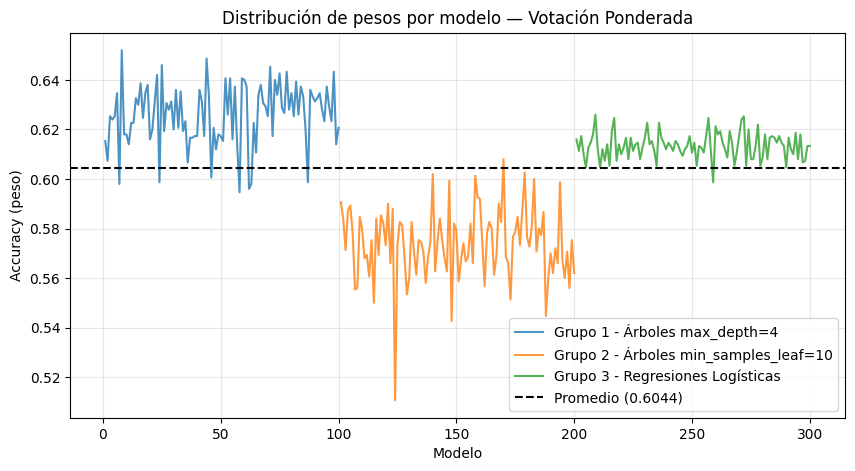


Peso promedio Grupo 1: 0.6260
Peso promedio Grupo 2: 0.5739
Peso promedio Grupo 3: 0.6135


In [ ]:
# Paso 2: Visualizar la distribución de pesos por grupo
plt.figure(figsize=(10, 5))
plt.plot(range(1, 101),   pesos[:100],   label='Grupo 1 - Árboles max_depth=4',       alpha=0.8)
plt.plot(range(101, 201), pesos[100:200], label='Grupo 2 - Árboles min_samples_leaf=10', alpha=0.8)
plt.plot(range(201, 301), pesos[200:],   label='Grupo 3 - Regresiones Logísticas',     alpha=0.8)
plt.axhline(pesos.mean(), color='black', linestyle='--', label=f'Promedio ({pesos.mean():.4f})')
plt.xlabel('Modelo')
plt.ylabel('Accuracy (peso)')
plt.title('Distribución de pesos por modelo — Votación Ponderada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nPeso promedio Grupo 1: {pesos[:100].mean():.4f}")
print(f"Peso promedio Grupo 2: {pesos[100:200].mean():.4f}")
print(f"Peso promedio Grupo 3: {pesos[200:].mean():.4f}")

In [ ]:
# -------------------------------------------------------
# Paso 3: Votación ponderada sobre los 300 modelos
# En lugar de promediar directamente (peso=1 para todos),
# se multiplica cada predicción por el accuracy del modelo
# -------------------------------------------------------

# Matriz de predicciones: shape (300, n_observaciones_test)
matriz_pred_pond = pd.DataFrame(resultados)  # Matriz del punto 7

# Multiplicar cada fila (modelo) por su peso (accuracy individual)
# pesos tiene shape (300,) → Se convierte a columna para multiplicar
matriz_ponderada = matriz_pred_pond.multiply(pesos, axis=0)

# Suma ponderada dividida entre la suma total de pesos
votos_ponderados = matriz_ponderada.sum(axis=0) / pesos.sum()

# Si la proporción ponderada >= 0.5 → predice 1, si no → predice 0
y_pred_ponderada = (votos_ponderados >= 0.5).astype(int)

print("Primeras 10 proporciones ponderadas:")
print(votos_ponderados.head(10).round(3).values)
print("\nPrimeras 10 predicciones finales:")
print(y_pred_ponderada.head(10).values)

Primeras 10 proporciones ponderadas:
[0.907 0.839 0.803 0.843 0.061 0.51  0.032 0.153 0.325 0.678]

Primeras 10 predicciones finales:
[1 1 1 1 0 1 0 0 0 1]


In [ ]:
# -------------------------------------------------------
# Paso 4: Evaluación ponderada por grupo independiente
# Aplicamos el mismo esquema de pesos pero solo
# dentro de cada grupo de 100 modelos
# -------------------------------------------------------

# Grupo 1 ponderado
pesos_g1        = pesos[:100]
matriz_pond_g1  = pd.DataFrame(resultados[:100]).multiply(pesos_g1, axis=0)
votos_g1_pond   = matriz_pond_g1.sum(axis=0) / pesos_g1.sum()
y_pred_g1_pond  = (votos_g1_pond >= 0.5).astype(int)

# Grupo 2 ponderado
pesos_g2        = pesos[100:200]
matriz_pond_g2  = pd.DataFrame(resultados[100:200]).multiply(pesos_g2, axis=0)
votos_g2_pond   = matriz_pond_g2.sum(axis=0) / pesos_g2.sum()
y_pred_g2_pond  = (votos_g2_pond >= 0.5).astype(int)

# Grupo 3 ponderado
pesos_g3        = pesos[200:]
matriz_pond_g3  = pd.DataFrame(resultados[200:]).multiply(pesos_g3, axis=0)
votos_g3_pond   = matriz_pond_g3.sum(axis=0) / pesos_g3.sum()
y_pred_g3_pond  = (votos_g3_pond >= 0.5).astype(int)

print("=== Evaluación individual ponderada por grupo ===\n")
print(f"{'Modelo':<40} {'Accuracy':>10} {'F1-Score':>10}")
print(f"{'Grupo 1 - Árboles max_depth=4':<40} {accuracy_score(y_test, y_pred_g1_pond):>10.4f} {f1_score(y_test, y_pred_g1_pond):>10.4f}")
print(f"{'Grupo 2 - Árboles min_samples_leaf=10':<40} {accuracy_score(y_test, y_pred_g2_pond):>10.4f} {f1_score(y_test, y_pred_g2_pond):>10.4f}")
print(f"{'Grupo 3 - Regresiones Logísticas':<40} {accuracy_score(y_test, y_pred_g3_pond):>10.4f} {f1_score(y_test, y_pred_g3_pond):>10.4f}")

=== Evaluación individual ponderada por grupo ===

Modelo                                     Accuracy   F1-Score
Grupo 1 - Árboles max_depth=4                0.6467     0.6380
Grupo 2 - Árboles min_samples_leaf=10        0.6573     0.6536
Grupo 3 - Regresiones Logísticas             0.6167     0.6048


In [ ]:
# -------------------------------------------------------
# Paso 5: Comparación final Punto 7 vs Punto 8
# -------------------------------------------------------
acc_pond = accuracy_score(y_test, y_pred_ponderada)
f1_pond  = f1_score(y_test, y_pred_ponderada)

print("=== Comparación final — Punto 7 vs Punto 8 ===\n")
print(f"{'Modelo':<40} {'Accuracy':>10} {'F1-Score':>10}")
print(f"{'--- Punto 7: Votación Mayoritaria ---':<40}")
print(f"{'Grupo 1 - Árboles max_depth=4':<40} {'0.6467':>10} {'0.6385':>10}")
print(f"{'Grupo 2 - Árboles min_samples_leaf=10':<40} {'0.6540':>10} {'0.6533':>10}")
print(f"{'Grupo 3 - Regresiones Logísticas':<40} {'0.6167':>10} {'0.6054':>10}")
print(f"{'Ensamble 300 (Votación Mayoritaria)':<40} {'0.6347':>10} {'0.6267':>10}")
print(f"\n{'--- Punto 8: Votación Ponderada ---':<40}")
print(f"{'Grupo 1 ponderado':<40} {accuracy_score(y_test, y_pred_g1_pond):>10.4f} {f1_score(y_test, y_pred_g1_pond):>10.4f}")
print(f"{'Grupo 2 ponderado':<40} {accuracy_score(y_test, y_pred_g2_pond):>10.4f} {f1_score(y_test, y_pred_g2_pond):>10.4f}")
print(f"{'Grupo 3 ponderado':<40} {accuracy_score(y_test, y_pred_g3_pond):>10.4f} {f1_score(y_test, y_pred_g3_pond):>10.4f}")
print(f"{'Ensamble 300 (Votación Ponderada)':<40} {acc_pond:>10.4f} {f1_pond:>10.4f}")


=== Comparación final — Punto 7 vs Punto 8 ===

Modelo                                     Accuracy   F1-Score
--- Punto 7: Votación Mayoritaria ---   
Grupo 1 - Árboles max_depth=4                0.6467     0.6385
Grupo 2 - Árboles min_samples_leaf=10        0.6540     0.6533
Grupo 3 - Regresiones Logísticas             0.6167     0.6054
Ensamble 300 (Votación Mayoritaria)          0.6347     0.6267

--- Punto 8: Votación Ponderada ---     
Grupo 1 ponderado                            0.6467     0.6380
Grupo 2 ponderado                            0.6573     0.6536
Grupo 3 ponderado                            0.6167     0.6048
Ensamble 300 (Votación Ponderada)            0.6347     0.6262


**Análisis de los resultados**

1. El ensamble ponderado no mejora al mayoritario a nivel global: ambos ensambles de 300 modelos obtienen exactamente 0.6347 de accuracy, con una diferencia mínima en F1 (0.6267 vs 0.6262). Esto sugiere que la ponderación por accuracy individual no aporta información diferenciadora cuando los pesos son similares entre sí.

2. La ponderación sí mejora el grupo 2 individualmente: el grupo 2 ponderado (0.6573) supera al grupo 2 mayoritario (0.6540), porque la ponderación da más peso a los mejores modelos dentro del grupo y penaliza los que cayeron hasta 0.51.

3. Los grupos 1 y 3 son prácticamente iguales entre mayoritaria y ponderada, lo que indica que dentro de estos grupos los modelos son  homogéneos y la ponderación no cambia el resultado.

4. Ningún ensamble supera al mejor grupo individual (grupo 2 ponderado: 0.6573), lo que sugiere que mezclar modelos débiles (regresiones logísticas) con modelos fuertes (árboles) diluye el desempeño del ensamble en este caso particular.

5. La gráfica de distribución de pesos revela información clave sobre el comportamiento de cada grupo. El grupo 1 (azul) se mantiene consistentemente por encima del promedio global (0.6044), con pesos entre 0.60 y 0.65, siendo los modelos más estables. El grupo 2 (naranja) muestra la mayor variabilidad, con pesos que oscilan entre 0.51 y 0.61, lo que explica su bajo peso promedio (0.5739) a pesar de tener el mejor desempeño agregado en el Punto 7. El grupo 3 (verde) es el más homogéneo de los tres, con pesos concentrados entre 0.60 y 0.62, lo que hace que en la ponderación no sea tan penalizado como podría esperarse dado su menor desempeño individual.

### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

Análisis y Comparación de Resultados — Puntos 7 y 8

1. Comparación entre metodologías

Las dos metodologías obtuvieron exactamente el mismo accuracy en el ensamble final de 300 modelos (0.6347), con una diferencia mínima en F1-Score (0.6267 vs 0.6262). Esto indica que en este caso particular, asignar pesos proporcionales al accuracy individual no aporta una mejora significativa sobre la votación simple.
La razón principal es que los pesos de los 300 modelos son relativamente similares entre sí (accuracy entre 0.51 y 0.65, con desviación estándar de apenas 0.025), por lo que la ponderación no logra diferenciar los buenos modelos de los malos.

2. Comparación a nivel de grupos

A nivel de grupos individuales sí se observa una diferencia: el grupop 2 ponderado (0.6573) supera al grupo 2 mayoritario (0.6540), porque la ponderación penaliza los modelos que cayeron hasta accuracy de 0.51 dentro del grupo, dando más influencia a los mejores. Los grupos 1 y 3 son prácticamente iguales entre metodologías, lo que indica que sus modelos internos son homogéneos y la ponderación no cambia el resultado.

3. Ventajas y desventajas de cada metodología

Votación Mayoritaria:

Ventajas: simple de implementar e interpretar, no requiere calcular métricas adicionales por modelo, y es robusta cuando todos los modelos tienen desempeño similar.

Desventajas: trata igual a modelos buenos y malos, un grupo de modelos débiles puede arrastrar el resultado hacia abajo, y no aprovecha la información sobre la calidad individual de cada modelo.

Votación Ponderada:

Ventajas: da más influencia a los modelos con mejor desempeño, penaliza automáticamente modelos inconsistentes, y es más flexible al permitir incorporar distintos criterios de peso.

Desventajas: más compleja de implementar, requiere una métrica de evaluación por modelo individual, y si los pesos son muy similares entre sí no aporta mejora significativa. Adicionalmente, existe riesgo de sobreajuste si los pesos se calculan sobre el mismo conjunto que se usa para evaluar el ensamble.

4. Conclusión final

Para este problema de clasificación de popularidad de noticias, ninguna de las dos metodologías logró superar al mejor modelo individual del Punto 6 (árbol con max_depth=4, accuracy=0.6513) de manera contundente. Esto sugiere que la diversidad entre los tres grupos de modelos no es suficiente para que el ensamble agregue valor real, principalmente porque combinar modelos fuertes (árboles de decisión) con modelos más débiles (regresiones logísticas) diluye el desempeño final del ensamble.